# Tree Genome Genotype

The **Tree Genome** is a direct, tree-structured representation used to encode the morphology of modular robots in ARIEL. Each genome directly represents a robot body as a rooted tree of modules, where the root is always a **core module** and each child node is connected to its parent via a specific face and rotation.

Unlike indirect encodings (such as the NDE), the tree genome is human-readable and maps one-to-one to the robot's physical topology — there is no neural network or decoding step required.

## Part 1: Overview

A tree genome is made up of two components:

* **Nodes** — a dictionary mapping an integer node ID to a module definition. Each module has:
    * A `type` (e.g. `CORE`, `ACTIVE_HINGE`, `BRICK`)
    * A `rotation` (e.g. `DEG_0`, `DEG_90`, `DEG_180`, `DEG_270`)

* **Edges** — a list of directed parent→child connections. Each edge specifies:
    * `parent`: the ID of the parent node
    * `child`: the ID of the child node
    * `face`: which face of the parent the child attaches to (e.g. `FRONT`, `LEFT`, `RIGHT`, `BACK`)

The tree always has a single root node — the **core** — with a fixed index (`IDX_OF_CORE`). All other modules are descendants of the core, and each node in the tree may only occupy one face of its parent.

![alt text](tree_docs_graph1.png)

The genome serialises to plain JSON, making it easy to save, load, and inspect. Internally it converts to a `networkx.DiGraph` compatible with ARIEL's `construct_mjspec_from_graph`.

## Part 2: Implementation

### Needed Imports

In [58]:
# OS import
import contextlib
import copy
from pathlib import Path

# Tree genome core
import mujoco as mj

# ARIEL config — module types, faces and rotations
from ariel.body_phenotypes.robogen_lite.config import (
    IDX_OF_CORE,
)

# Robot construction and visualisation
from ariel.body_phenotypes.robogen_lite.constructor import construct_mjspec_from_graph
from ariel.ec.genotypes.tree.io import load_genome, save_genome
from ariel.ec.genotypes.tree.operators_1 import (
    add_node,
    crossover_subtree,
    get_tree_depth,
    mutate_hoist,
    mutate_replace_node,
    mutate_shrink,
    mutate_subtree_replacement,
    random_tree,
    validate_tree_depth,
)
from ariel.ec.genotypes.tree.tree_genome import TreeGenome
from ariel.ec.genotypes.tree.validation_1 import validate_genome_dict
from ariel.simulation.environments import SimpleFlatWorld
from ariel.utils.renderers import single_frame_renderer

path = Path.cwd()

### Creating a Genome Manually

A `TreeGenome` can be constructed by hand. The only requirement is that the genome contains a core node at `IDX_OF_CORE` (which is `0` by default). All other nodes are attached as children via edges.

In [76]:
# Build a simple genome by hand
genome = TreeGenome()

# Every genome must start with a CORE node at IDX_OF_CORE
genome.nodes[IDX_OF_CORE] = {"type": "CORE", "rotation": "DEG_0"}

# Add child modules using add_node(genome, parent_id, face, new_id, type, rotation)

# Add hinge to the front of the core
add_node(
    genome,
    parent=IDX_OF_CORE,
    face="FRONT",
    node_id=1,
    mtype="ACTIVE_HINGE",
    rotation="DEG_0",
)

# Add brick to the right of the core
add_node(
    genome,
    parent=IDX_OF_CORE,
    face="RIGHT",
    node_id=2,
    mtype="BRICK",
    rotation="DEG_0",
)

# Add brick to the front of the hinge on the front of the core
add_node(
    genome,
    parent=1,
    face="FRONT",
    node_id=3,
    mtype="BRICK",
    rotation="DEG_0",
)

# Add hinge to the brick on the right side of the core
add_node(
    genome,
    parent=2,
    face="FRONT",
    node_id=4,
    mtype="ACTIVE_HINGE",
    rotation="DEG_90",
)


### Generating a Random Genome

The `random_tree` function creates a valid genome by starting with only the core and repeatedly attaching randomly chosen modules to available free faces, until the specified module budget is reached or no free slots remain.

In [77]:
# Generate a random tree with up to 10 modules (including core)
genome = random_tree(max_modules=10)

# How to get the nodes and their data
for _nid, _ndata in genome.nodes.items():
    pass

# How to get the edges
for _e in genome.edges:
    pass

### Serialisation: JSON Load / Save

Tree genomes can be saved to and loaded from plain JSON files. This makes it easy to checkpoint populations, share genomes, and inspect them in any text editor.

In [78]:
# # Save to JSON
save_genome(genome, path / "my_genome.json")

# Load back
loaded = load_genome(path / "my_genome.json")

# Inspect raw JSON
with Path(path / "my_genome.json").open(encoding="utf-8") as f:
    pass

You can also serialise to/from a plain Python dictionary, which is how genotypes are stored inside ARIEL `Individual` objects:

In [79]:
# Convert genome → dict (e.g. to store in Individual.genotype)
genome_dict = genome.to_dict()

# Reconstruct genome from dict
genome_restored = TreeGenome.from_dict(genome_dict)


## Part 3: Validation

The `validate_genome_dict` function performs a full structural check of the genome. It verifies:
* The core node is present at `IDX_OF_CORE`
* All node types and rotations are valid enum members
* All faces used in edges are allowed for the parent's module type
* No face is occupied by more than one child
* The genome forms a single connected tree rooted at the core

In [63]:
# Validate a genome — raises ValueError if invalid, returns None if valid
with contextlib.suppress(ValueError):
    validate_genome_dict(genome.to_dict())

In [64]:
# Example of a validation failure — core missing
bad_genome = TreeGenome()
bad_genome.nodes[99] = {"type": "BRICK", "rotation": "DEG_0"}  # No core!

with contextlib.suppress(ValueError):
    validate_genome_dict(bad_genome.to_dict())

You can also check tree depth constraints separately, which is useful during evolution to guard against bloat:

In [65]:
MAX_DEPTH = 12

depth = get_tree_depth(genome)
within_limit = validate_tree_depth(genome, MAX_DEPTH)


## Part 4: Robot Blueprint

The tree genome's primary purpose is to represent a modular robot body. It converts to a `networkx.DiGraph` that is directly compatible with ARIEL's `construct_mjspec_from_graph` function — no intermediate decoding step is needed.

In [66]:
# Convert genome to a networkx directed graph
robot_graph = genome.to_networkx()

# for _nid, data in robot_graph.nodes(data=True):
#     pass

# for _u, _v, data in robot_graph.edges(data=True):
#     pass

In [67]:
# Build a MuJoCo model specification from the robot graph
robot_spec = construct_mjspec_from_graph(robot_graph).spec

### Spawn Robot in Simulation

With the MuJoCo specification built, we can spawn the robot into a world and render it.

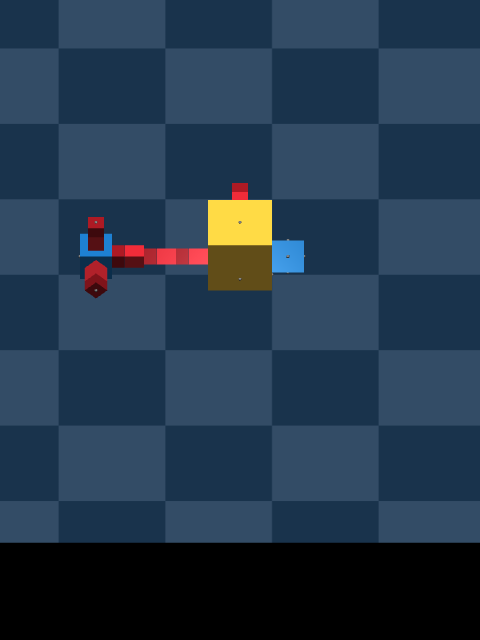

In [87]:
# Spawn in a flat world and render
world = SimpleFlatWorld()
world.spawn(robot_spec)

model = world.spec.compile()
data = mj.MjData(model)

single_frame_renderer(
    model,
    data,
    cam_fovy=2,
    cam_pos=(-0.7, 0.1, 0.5),
)

## Part 5: Evolutionary Operators

The tree genome includes a full suite of genetic operators drawn from canonical Genetic Programming (Koza, 1992). Since the genome is a tree rather than a vector, operators work by manipulating **subtrees** rather than splicing flat arrays.

All operators respect the module face constraints (a face that is not allowed for a given module type will never be used) and will silently no-op or fall back to valid states if an operation would produce an invalid genome.

---

### Crossover

**Subtree crossover** (`crossover_subtree`) selects a random non-core node from each of two parent genomes and swaps the subtrees rooted at those nodes. This is the standard GP crossover operator. It returns two offspring and leaves the parents unmodified.

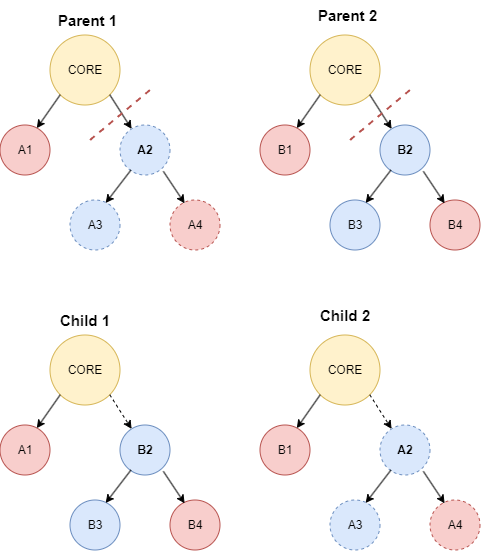

In [ ]:
# Example Crossover
parent_a = random_tree(max_modules=20)
parent_b = random_tree(max_modules=20)

child1, child2 = crossover_subtree(parent_a, parent_b)


### Mutation

Four mutation operators are available, each modifying the genome in-place:

| Operator | Description |
|---|---|
| `mutate_replace_node` | **Point mutation** — replaces a random non-core node's type and rotation with a new random valid choice. Children on faces no longer allowed by the new type are pruned. |
| `mutate_subtree_replacement` | **Subtree mutation** — removes a random subtree and replaces it with a newly generated random subtree. Equivalent to Koza's *headless chicken* crossover. |
| `mutate_shrink` | **Shrink mutation** — replaces a node and its entire subtree with a single new leaf node, reducing tree size. |
| `mutate_hoist` | **Hoist mutation** — replaces a non-core node with one of its children, effectively shortening a branch. |

In [70]:
# Point mutation: change a node's type / rotation
genome_pm = copy.deepcopy(genome)
mutate_replace_node(genome_pm)
validate_genome_dict(genome_pm.to_dict())

In [71]:
# Subtree mutation: replace a random subtree with a new random one
genome_sm = copy.deepcopy(genome)
mutate_subtree_replacement(genome_sm, max_modules=10)
validate_genome_dict(genome_sm.to_dict())

In [72]:
# Shrink mutation: collapse a subtree down to a single leaf
genome_sh = copy.deepcopy(genome)
before = len(genome_sh.nodes)
mutate_shrink(genome_sh)
validate_genome_dict(genome_sh.to_dict())

In [73]:
# Hoist mutation: replace a node with one of its children
genome_ho = copy.deepcopy(genome)
before = len(genome_ho.nodes)
mutate_hoist(genome_ho)
validate_genome_dict(genome_ho.to_dict())

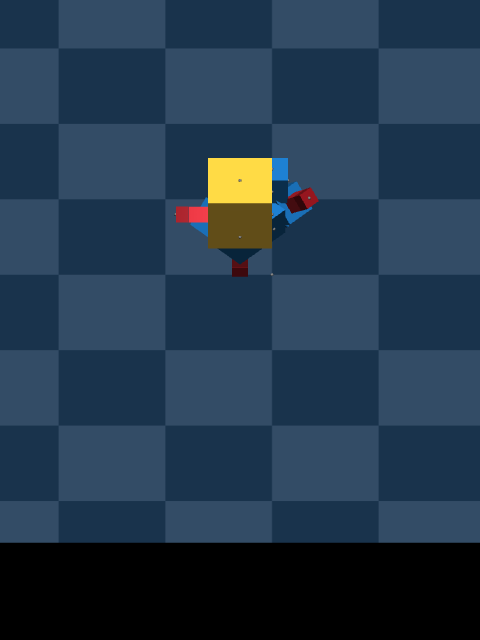

In [93]:
# Build a MuJoCo model specification from the robot graph
robot_spec = construct_mjspec_from_graph(genome_pm.to_networkx()).spec

world = SimpleFlatWorld()
world.spawn(robot_spec)

model = world.spec.compile()
data = mj.MjData(model)

single_frame_renderer(
    model,
    data,
    cam_fovy=2,
    cam_pos=(-0.7, 0.1, 0.5),
)